# Max value and data columns check

In [1]:
import os
import pandas as pd
from my_helpers import *

In [2]:
%load_ext autoreload
%autoreload 2

In [40]:
folder_path = '../data'  
max_values = []  
min_values = []  
separators = ' '
corrupted_files = ['../data/DATA2803/6ALEXANDRA/ALEXANDRA_5_DT_100_rawdata.csv','../data/DATA2803/6ALEXANDRA/ALEXANDRA_4_DQ_100_rawdata.csv','../data/DATA2903/7Jules']
sniffer = csv.Sniffer()
cap_text_cols = ['TimeStamps', 'MergeTimeStamps', 'ScanSizeX', 'ScanSizeY']
cap_numeric_cols =  list(map(str,range(3024)))
cap_cols = cap_text_cols + cap_numeric_cols
processed_cap_cols = cap_text_cols + ['cap_img','trial','gesture','subject','day']
wrist_cols = ['wrist_x','wrist_y','wrist_z']
finger_cols = sum([[f'{x}_{y}_x', f'{x}_{y}_y', f'{x}_{y}_z'] for x in ['Thumb','Index','Middle','Ring','Pinky'] for y in range(5)],[]) 
skel_cols = ['Timestamp'] + wrist_cols + finger_cols

subject = 0
day = 0

# Loop through each day data folder
for folder in os.listdir(folder_path):

    if not folder.startswith('DATA'):  
        continue

    path = os.path.join(folder_path, folder)
    day_data = pd.DataFrame(columns=cap_text_cols + ['cap_img'])

    # Loop through each kid data folder
    for kid in os.listdir(path):

        kid_folder = os.path.join(path, kid)

        if(kid_folder) in corrupted_files:
            continue

        skeleton_file = [f for f in os.listdir(kid_folder) if f.endswith('handleap.csv')]

        if len(skeleton_file) != 1:
            #1 occurence of this error
            raise ValueError('Found more than one skeleton file')
        
        skeleton_path = os.path.join(kid_folder, skeleton_file[0])
        skeleton_data = read_skeleton(skeleton_path,sniffer,skel_cols)
        kid_cap = pd.DataFrame(columns=processed_cap_cols)

        # Loop through each gesture data, process and concatenate
        for filename in os.listdir(kid_folder):
            if filename.endswith('rawdata.csv'):  # Check only files that end with'rawdata.csv'r
                file_path = os.path.join(kid_folder, filename)
                
                if (file_path in corrupted_files) :
                    continue

                print(file_path)

                cap_img = read_cap_img(file_path,sniffer,cap_cols)
                
                #check for max and min values of capactive images pixels
                max_value = cap_img[cap_numeric_cols].values.max()
                min_value = cap_img[cap_numeric_cols].values.min()
                max_values.append(max_value)
                min_values.append(min_value)

                cap_img = process_cap_img(cap_img,trunc=True)
                
                f = filename.split('_')
                trial , gesture = f[1], f[2]

                #add folders informatiom to data
                cap_img['trial'] = trial
                cap_img['gesture'] = gesture
                cap_img['subject'] = subject
                cap_img['day'] = day

                
                
                kid_cap = pd.concat([kid_cap,cap_img],ignore_index=True)
        #ŦO DO : add skeleton data to kid_cap
        #merge(kid_cap,skeleton_data)
        #add result to day data
        display(kid_cap) 
        subject+=1 
    #day_data.to_pickle(f'../data/processed/day{day}.pkl')
    day+=1      

../data/DATA3003/16Yaman/YAMAN_3_DQ_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_4_LQ_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_1_UP_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_5_LT_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_2_DT_100_rawdata.csv
../data/DATA3003/16Yaman/YAMAN_6_UP_100_rawdata.csv


,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img,trial,gesture,subject,day
0,1680168266364,1680168266360,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,DQ,0,0
1,1680168266376,1680168266375,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,DQ,0,0
2,1680168266390,1680168266390,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,DQ,0,0
3,1680168266403,1680168266400,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,DQ,0,0
4,1680168266417,1680168266415,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,DQ,0,0
...,...,...,...,...,...,...,...,...,...
24584,1680168874922,1680168874920,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,0,0
24585,1680168874932,1680168874930,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,0,0
24586,1680168874946,1680168874945,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,0,0
24587,1680168874956,1680168874955,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,0,0


../data/DATA3003/15Clemence/CLEMENCE_4_LT_100_rawdata.csv


,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img,trial,gesture,subject,day
0,1680166687668,1680166687665,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LT,1,0
1,1680166687687,1680166687685,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LT,1,0
2,1680166687700,1680166687700,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LT,1,0
3,1680166687713,1680166687710,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LT,1,0
4,1680166687725,1680166687725,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LT,1,0
5,1680166687739,1680166687735,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LT,1,0


../data/DATA3003/21AnnaSofia/ANNA SOFIA_4_DQ_100_rawdata.csv
../data/DATA3003/21AnnaSofia/ANNA SOFIA_1_UP_100_rawdata.csv


...

../data/DATA2903/12Leonie/LEONIE_4_LQ_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_2_DT_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_3_DQ_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_1_UP_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_5_LT_100_rawdata.csv
../data/DATA2903/12Leonie/LEONIE_6_UP_100_rawdata.csv


,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img,trial,gesture,subject,day
0,1680095561461,1680095561460,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LQ,31,4
1,1680095561472,1680095561470,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LQ,31,4
2,1680095561485,1680095561485,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LQ,31,4
3,1680095561497,1680095561495,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LQ,31,4
4,1680095561821,1680095561820,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",4,LQ,31,4
...,...,...,...,...,...,...,...,...,...
30101,1680096108094,1680096108090,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,31,4
30102,1680096108104,1680096108100,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,31,4
30103,1680096108118,1680096108115,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,31,4
30104,1680096108132,1680096108130,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,31,4


,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img,trial,gesture,subject,day


../data/DATA2903/11Tommaso/TOMMASO_6_UP_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_5_DQ_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_3_DT_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_2_LQ_100_rawdata.csv
../data/DATA2903/11Tommaso/TOMMASO_1_UP_100_rawdata.csv


,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img,trial,gesture,subject,day
0,1680094006700,1680094006700,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,33,4
1,1680094006713,1680094006710,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,33,4
2,1680094006725,1680094006725,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,33,4
3,1680094006735,1680094006735,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,33,4
4,1680094006747,1680094006745,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",6,UP,33,4
...,...,...,...,...,...,...,...,...,...
22304,1680093037847,1680093037845,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,UP,33,4
22305,1680093037860,1680093037860,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,UP,33,4
22306,1680093037873,1680093037870,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,UP,33,4
22307,1680093037887,1680093037885,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,UP,33,4


In [31]:
separators

' ,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,'

In [17]:
skel_cols

['wrist_x',
 'wrist_y',
 'wrist_z',
 'Thumb_0_x',
 'Thumb_0_y',
 'Thumb_0_z',
 'Thumb_1_x',
 'Thumb_1_y',
 'Thumb_1_z',
 'Thumb_2_x',
 'Thumb_2_y',
 'Thumb_2_z',
 'Thumb_3_x',
 'Thumb_3_y',
 'Thumb_3_z',
 'Thumb_4_x',
 'Thumb_4_y',
 'Thumb_4_z',
 'Index_0_x',
 'Index_0_y',
 'Index_0_z',
 'Index_1_x',
 'Index_1_y',
 'Index_1_z',
 'Index_2_x',
 'Index_2_y',
 'Index_2_z',
 'Index_3_x',
 'Index_3_y',
 'Index_3_z',
 'Index_4_x',
 'Index_4_y',
 'Index_4_z',
 'Middle_0_x',
 'Middle_0_y',
 'Middle_0_z',
 'Middle_1_x',
 'Middle_1_y',
 'Middle_1_z',
 'Middle_2_x',
 'Middle_2_y',
 'Middle_2_z',
 'Middle_3_x',
 'Middle_3_y',
 'Middle_3_z',
 'Middle_4_x',
 'Middle_4_y',
 'Middle_4_z',
 'Ring_0_x',
 'Ring_0_y',
 'Ring_0_z',
 'Ring_1_x',
 'Ring_1_y',
 'Ring_1_z',
 'Ring_2_x',
 'Ring_2_y',
 'Ring_2_z',
 'Ring_3_x',
 'Ring_3_y',
 'Ring_3_z',
 'Ring_4_x',
 'Ring_4_y',
 'Ring_4_z',
 'Pinky_0_x',
 'Pinky_0_y',
 'Pinky_0_z',
 'Pinky_1_x',
 'Pinky_1_y',
 'Pinky_1_z',
 'Pinky_2_x',
 'Pinky_2_y',
 'Pinky_2_z'

In [37]:
files =os.listdir('../data/DATA3003/16Yaman/')
skeleton_data = [f for f in files if f.endswith('handleap.csv')]
skeleton_data[0]

'useryaman_2023-03-30_11-35-18_1644_handleap.csv'

In [32]:
df=pd.read_csv('../data/DATA3003/16Yaman/YAMAN_3_DQ_100_rawdata.csv',sep=' ')
pixels= df[numeric_cols]
df= process_cap_img(df,trunc=True)
df

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img
0,1680168266364,1680168266360,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,1680168266376,1680168266375,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,1680168266390,1680168266390,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,1680168266403,1680168266400,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,1680168266417,1680168266415,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
...,...,...,...,...,...
3035,1680168349016,1680168349015,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3036,1680168349029,1680168349025,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3037,1680168349040,1680168349040,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3038,1680168349053,1680168349050,72,41,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [20]:
type(b[0])

list

In [7]:
ds = pd.read_pickle('../data/processed/day0.pkl')
ds

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,cap_img,trial,gesture,subject,day
0,1680168266364,1680168266360,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
1,1680168266376,1680168266375,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
2,1680168266390,1680168266390,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
3,1680168266403,1680168266400,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
4,1680168266417,1680168266415,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DQ,0.0,0.0
...,...,...,...,...,...,...,...,...,...
171409,1680165018686,1680165018685,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0
171410,1680165020325,1680165020325,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0
171411,1680165020335,1680165020335,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0
171412,1680165020352,1680165020350,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",3,DT,8.0,0.0


In [2]:
print(max(max_values))
print(min((min_values)))

3023
0


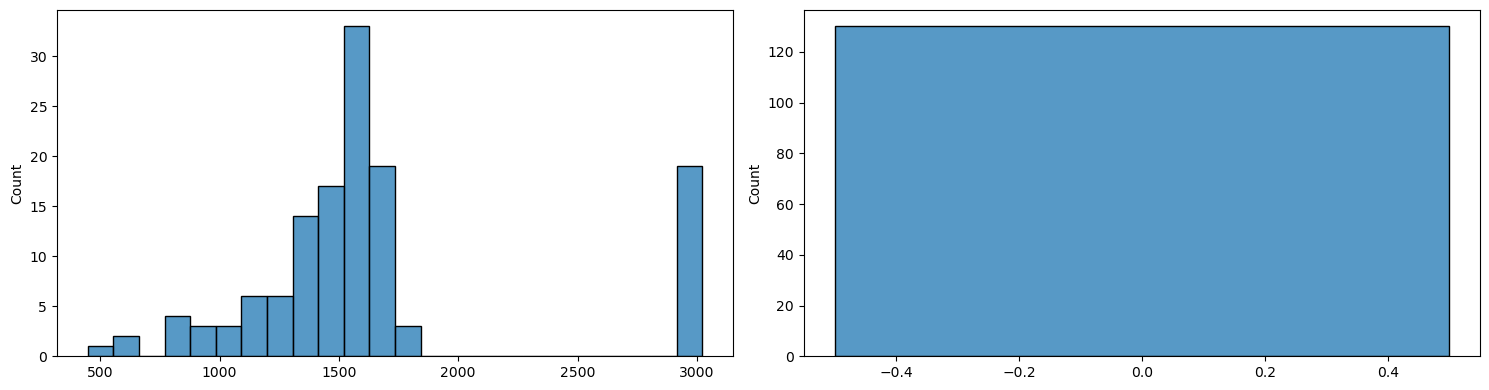

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

ax, fig = plt.subplots(1,2,figsize=(15,4))
sns.histplot(max_values, ax=fig[0])
sns.histplot(min_values, ax=fig[1])
plt.tight_layout()

In [33]:
import glob

files = glob.glob(folder_path+)
#df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
files

['../data/']

In [34]:
df

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,0,1,2,3,4,5,...,3014,3015,3016,3017,3018,3019,3020,3021,3022,3023
0,1680092958165,1680092958165,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1680092958174,1680092958170,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1680092958187,1680092958185,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1680092958199,1680092958195,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1680092958208,1680092958205,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,1680093037847,1680093037845,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
73,1680093037860,1680093037860,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
74,1680093037873,1680093037870,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
75,1680093037887,1680093037885,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
d = {'DT': 'Dynamic Tripod', 
     'DQ': 'Dynamic Quadrupod', 
     'LT': 'Lateral Tripod', 
     'LQ': 'Lateral Quadrupod',
     'UP': 'Native'}